In [ ]:
# from astroquery.esa.euclid import Euclid
# from astropy.coordinates import SkyCoord
# import astropy.units as u

ModuleNotFoundError: No module named 'astroquery'

In [ ]:
# coord = SkyCoord("17h51m07.4s +65d31m50.8s", frame='icrs') #not correct
# radius = u.Quantity(1.0, u.deg)
# job = Euclid.cone_search(coordinate=coord, radius=radius, table_name="sedm.mosaic_product", ra_column_name="ra", dec_column_name="dec", columns="*", async_job=True)

# cone_results = job.get_results()
# print("Found", len(cone_results), "results")


In [8]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS   # In order to get the shift for overlaying frames

import lacosmic # for cosmic ray detection

import sep

from os import listdir

from mgefit.find_galaxy import find_galaxy

# from sourcemasking import obtainSextractorSources

In [3]:
hdul = fits.open('ERO-Dorado/Euclid-VIS-ERO-Dorado-Flattened.DR3.fits/Euclid-VIS-ERO-Dorado-Flattened.v3.fits')

In [ ]:
hdul.info()

full_data = hdul[0].data
full_header = hdul[0].header

hdul.close()

Filename: ERO-Dorado/Euclid-VIS-ERO-Dorado-Flattened.DR3.fits/Euclid-VIS-ERO-Dorado-Flattened.v3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      85   (36000, 36000)   float32   


In [7]:
full_header

SIMPLE  =                    T / This is a FITS file                            
BITPIX  =                  -32 /                                                
NAXIS   =                    2 /                                                
NAXIS1  =                36000 / NUMBER OF ELEMENTS ALONG THIS AXIS             
NAXIS2  =                36000 / NUMBER OF ELEMENTS ALONG THIS AXIS             
EXTEND  =                    T / This file may contain FITS extensions          
EQUINOX =        2000.00000000 / Mean equinox                                   
RADESYS = 'ICRS    '           / Astrometric system                             
CTYPE1  = 'RA---TAN'           / WCS projection type for this axis              
CUNIT1  = 'deg     '           / Axis unit                                      
CRVAL1  =   6.401433700000E+01 / World coordinate on this axis                  
CRPIX1  =   1.800050000000E+04 / Reference pixel on this axis                   
CD1_1   =  -2.777777777778E-

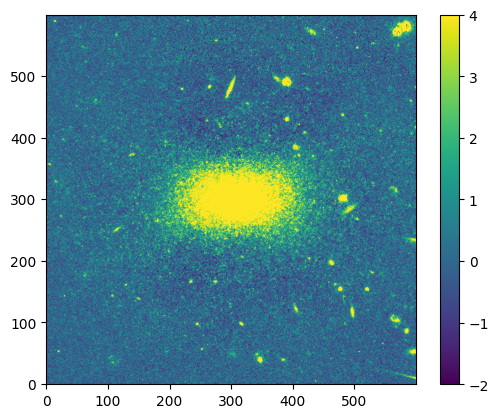

In [15]:
coorx, coory = 27662, 20615
size = 300

data = full_data[coory-size:coory+size, coorx-size:coorx+size]

plt.imshow(data, origin='lower', vmin=-2, vmax=4)
plt.colorbar()
plt.show()

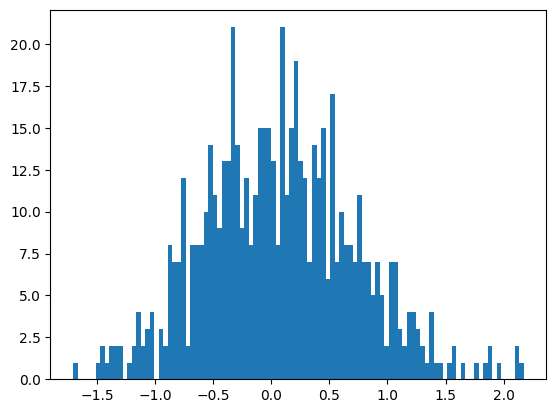

-32.538803 3990.1838 0.18331449 0.63047475 13.889778


In [17]:
plt.hist(data[150,:], bins=100)
plt.show()
# check the data values
print(np.min(data), np.max(data), np.median(data), np.mean(data), np.std(data))

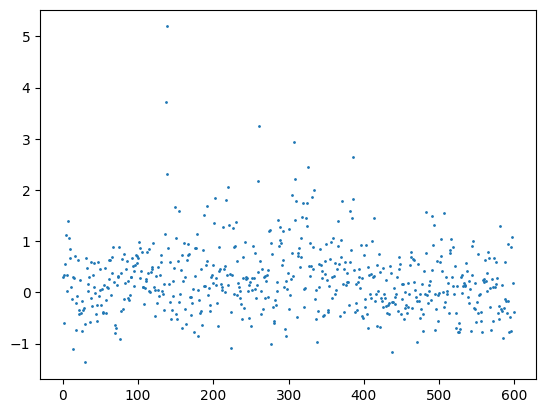

In [16]:
plt.scatter(np.arange(data.shape[0]), data[:, 150], s=1)
plt.show()
# not oversaturated

In [18]:
fits.writeto('cavia.fits', data, header=full_header, overwrite=True)

In [9]:
hdul = fits.open('ERO-Dorado/Euclid-VIS-ERO-Dorado-LSB.DR3.fits/Euclid-VIS-ERO-Dorado-LSB.v3.fits')
hdul.info()

full_data = hdul[0].data
full_header = hdul[0].header

hdul.close()

Filename: ERO-Dorado/Euclid-VIS-ERO-Dorado-LSB.DR3.fits/Euclid-VIS-ERO-Dorado-LSB.v3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     179   (36000, 36000)   float32   


In [10]:
full_header

SIMPLE  =                    T / This is a FITS file                            
BITPIX  =                  -32 / Bits per pixel                                 
NAXIS   =                    2 /                                                
NAXIS1  =                36000 / NUMBER OF ELEMENTS ALONG THIS AXIS             
NAXIS2  =                36000 / NUMBER OF ELEMENTS ALONG THIS AXIS             
EXTEND  =                    T / This file may contain FITS extensions          
EQUINOX =        2000.00000000 / Mean equinox                                   
RADESYS = 'ICRS    '           / Astrometric system                             
CTYPE1  = 'RA---TAN'           / WCS projection type for this axis              
CUNIT1  = 'deg     '           / Axis unit                                      
CRVAL1  =   6.401433700000E+01 / World coordinate on this axis                  
CRPIX1  =   1.800050000000E+04 / Reference pixel on this axis                   
CD1_1   =  -2.777777777778E-

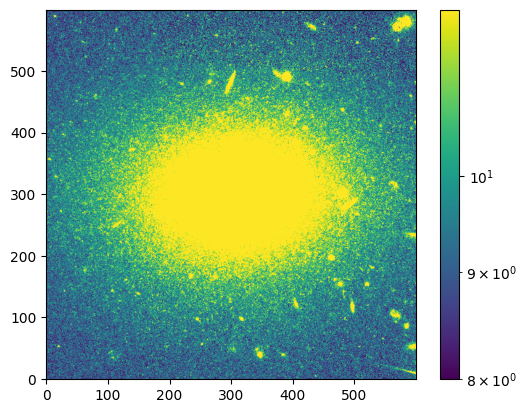

In [23]:
coorx, coory = 27662, 20615
size = 300

data2 = full_data[coory-size:coory+size, coorx-size:coorx+size]

plt.imshow(data2, origin='lower', norm='log', vmin=8, vmax=12)
plt.colorbar()
plt.show()

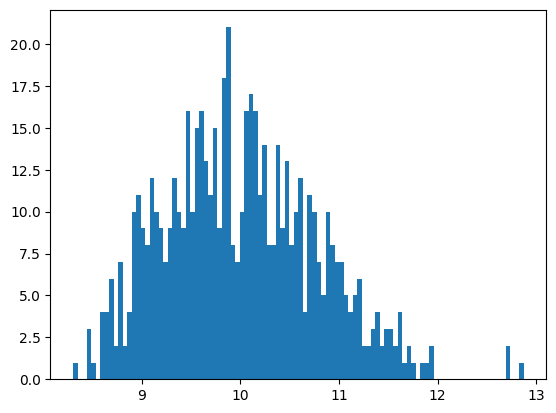

5.399539 3693.7542 9.933117 10.848693 13.812262


In [28]:
plt.hist(data2[150,:], bins=100)
plt.show()
# check the data values
print(np.nanmin(data2), np.nanmax(data2), np.nanmedian(data2), np.nanmean(data2), np.nanstd(data2))

(600, 600)
[[571 571]]


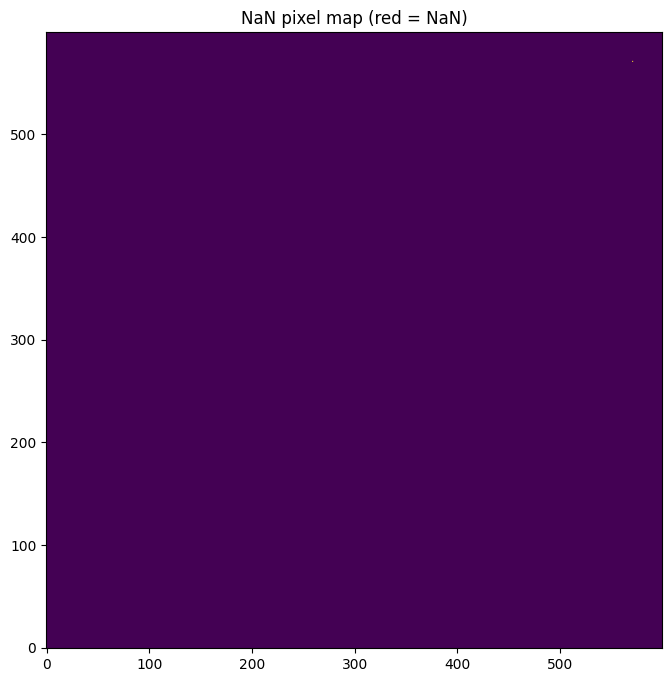

In [27]:
print(np.shape(data2))
print(np.argwhere(np.isnan(data2)))
fig = plt.figure(figsize=(8, 8))
plt.imshow(np.isnan(data2), origin='lower')
plt.title("NaN pixel map (red = NaN)")
plt.show()

In [30]:
data2_nn = np.nan_to_num(data2, nan=np.nanmedian(data2))

In [32]:
print(np.argwhere(data2_nn == np.min(data2_nn)))
print(data2_nn[571,571])

[[588 466]]
9.933117


In [ ]:
fits.writeto('caviaLSB/flt/cavia.fits', data2_nn, header=full_header, overwrite=True)

In [34]:
hdul = fits.open('ERO-Dorado/Euclid-VIS-Mask-ERO-Dorado-LSB.DR3.fits/Euclid-VIS-Mask-ERO-Dorado-LSB.v3.fits')
hdul.info()

Filename: ERO-Dorado/Euclid-VIS-Mask-ERO-Dorado-LSB.DR3.fits/Euclid-VIS-Mask-ERO-Dorado-LSB.v3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      58   (36000, 36000)   float32   


In [35]:
full_data = hdul[0].data
full_header = hdul[0].header

hdul.close()

In [36]:
full_header

SIMPLE  =                    T / This is a FITS file                            
BITPIX  =                  -32 /                                                
NAXIS   =                    2 /                                                
NAXIS1  =                36000 / NUMBER OF ELEMENTS ALONG THIS AXIS             
NAXIS2  =                36000 / NUMBER OF ELEMENTS ALONG THIS AXIS             
EXTEND  =                    T / This file may contain FITS extensions          
EQUINOX =        2000.00000000 / Mean equinox                                   
RADESYS = 'ICRS    '           / Astrometric system                             
CTYPE1  = 'RA---TAN'           / WCS projection type for this axis              
CUNIT1  = 'deg     '           / Axis unit                                      
CRVAL1  =   6.401433700000E+01 / World coordinate on this axis                  
CRPIX1  =   1.800050000000E+04 / Reference pixel on this axis                   
CD1_1   =  -2.777777777778E-

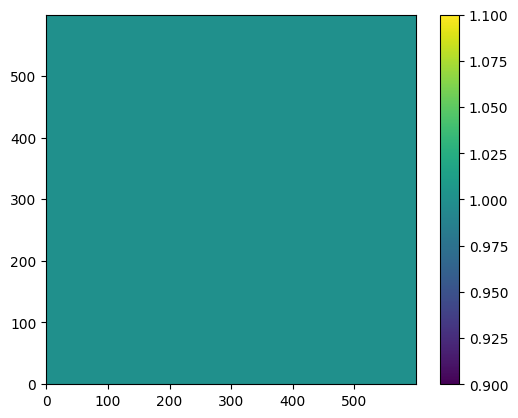

In [ ]:
datam = full_data[coory-size:coory+size, coorx-size:coorx+size]

plt.imshow(datam, origin='lower')#, norm='log', vmin=8, vmax=12)
plt.colorbar()
plt.show()

In [48]:
print(np.min(datam), np.max(datam))

# so the mask is useless here
# plt.hist(datam)
# plt.show()

1.0 1.0
